# Семинар II: Предсказание Z-DNA с помощью графовых нейросетей

## Введение

**Z-DNA** - это левозакрученная конформация двойной спирали ДНК, которая играет важную роль в регуляции генов и других клеточных процессах. В этом практическом занятии мы будем решать задачу бинарной классификации - предсказывать участки ДНК, которые могут формировать Z-конформацию.

**Используемые технологии:**
- PyTorch Geometric для графовых нейросетей
- Optuna для подбора гиперпараметров
- MLflow для логирования экспериментов
- Captum для интерпретации моделей

## Этап 1. Загрузка данных и подготовка датасета


In [37]:
#!pip install torch-geometric -q
#!git clone https://github.com/vladislareon/Sparse_vector
#!git clone https://github.com/vladislareon/z_dna.git

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Основные библиотеки для файловых операций, численных вычислений и обработки данных
import os
import numpy as np
import pandas as pd

# Инструменты визуализации
import matplotlib.pyplot as plt

# Индикаторы прогресса для итеративных операций
from tqdm import tqdm
import sys
import time
tqdm.pandas()  # Включение индикаторов прогресса для pandas

# import pandarallel

# Метрики для оценки модели
from sklearn.metrics import roc_auc_score, f1_score
from IPython.display import clear_output  # Для очистки вывода ноутбука

# Утилита для эффективного сохранения/загрузки объектов Python
from joblib import load
from tqdm import trange
from tqdm.notebook import tqdm  # Индикаторы прогресса специально для Jupyter notebook

# Библиотеки PyTorch Geometric для графовых нейронных сетей
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset, Data

# Предобработка данных и валидация
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import StratifiedKFold  # Для стратифицированной кросс-валидации

# Модули нейронных сетей PyTorch и PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GraphConv, GATConv, GATv2Conv, SAGEConv  # Различные типы слоев GNN

# Кастомное представление разреженного вектора для эффективной обработки последовательностей ДНК
from Sparse_vector.sparse_vector import SparseVector

### Функциональные группы геномных признаков (Epigenetic & Genomic Features)

В пайплайне используются четыре основные группы геномных и эпигенетических признаков, которые помогают модели лучше предсказывать целевые участки (Z-ДНК):

* **DNase-seq (Открытый хроматин):** Данные о гиперчувствительности к ДНКазе I. Они показывают участки «открытого» хроматина, где ДНК не намотана плотно на нуклеосомы и доступна для связывания с регуляторными белками.
* **Histone (Гистоновые модификации):** Эпигенетические маркеры (такие как метилирование или ацетилирование гистонов). Они позволяют определить структурное и функциональное состояние хроматина, указывая на активные или репрессированные промоторы, энхансеры и другие регуляторные элементы.
* **RNA polymerase (РНК-полимераза):** Участки связывания РНК-полимеразы (чаще всего Pol II). Поскольку этот фермент осуществляет синтез РНК на матрице ДНК, такие признаки размечают регионы с активной транскрипцией.
* **TFs and others (Транскрипционные факторы и другие белки):** Данные о связывании специфических ДНК-связывающих белков. Транскрипционные факторы распознают определенные мотивы ДНК и регулируют экспрессию генов, часто взаимодействуя с открытым хроматином.

In [3]:
# Список всех хромосом человека в формате, как в файлах/аннотациях (chr1, ..., chr22, chrX, chrY, chrM)
chrom_names = [f'chr{i}' for i in list(range(1, 23)) + ['X', 'Y', 'M']]

# Получаем список всех доступных файлов с признаками (epigenetic / genomic features) и отрезаем расширение .pkl
features = [i[:-4] for i in os.listdir('z_dna/hg38_features/sparse/') if i.endswith('.pkl')]

# Логические/биологические группы признаков: открытый хроматин, гистоновые модификации, РНК-полимераза, транскрипционные факторы и др.
groups = ['DNase-seq', 'Histone', 'RNA polymerase', 'TFs and others']

# Удобный список имен признаков, с которыми дальше работает модель
feature_names = [i for i in features]

In [4]:
def chrom_reader(chrom):
    """
    Загружает и склеивает фрагменты ДНК‑последовательности для заданной хромосомы.

    Args:
        chrom: Идентификатор хромосомы (например, 'chr1').

    Returns:
        Единую строку с полным нуклеотидным рядом для этой хромосомы.
    """
    # Находим все файлы с фрагментами ДНК для нужной хромосомы и сортируем их по имени
    files = sorted([i for i in os.listdir('z_dna/hg38_dna/') if f"{chrom}_" in i])

    # Загружаем все фрагменты и объединяем их в одну длинную строку
    return ''.join([load(f"z_dna/hg38_dna/{file}") for file in files])

In [5]:
%%time
# Считываем полную ДНК-последовательность для каждой хромосомы
DNA = {chrom: chrom_reader(chrom) for chrom in tqdm(chrom_names)}

# Загружаем разреженное представление Z-ДНК (метки потенциальных Z-DNA регионов по геному)
ZDNA = load('z_dna/hg38_zdna/sparse/ZDNA_cousine.pkl')

# Загружаем все доступные геномные/эпигенетические признаки (DNase-seq, гистоны, РНК-полимераза, TF и др.)
DNA_features = {
    feature: load(f'z_dna/hg38_features/sparse/{feature}.pkl')
    for feature in tqdm(feature_names)
}

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/1946 [00:00<?, ?it/s]

CPU times: user 49 s, sys: 4.43 s, total: 53.5 s
Wall time: 56 s


In [6]:
DNA['chr1'][:100]

'NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN'

### Подготовка и балансировка данных (Сборка датасета)

В следующих ячейках мы подготавливаем данные для обучения модели. Поскольку участков с Z-ДНК в геноме гораздо меньше, чем обычных участков, нам нужно сбалансировать классы, чтобы модель не стала предсказывать только негативный класс.

Процесс состоит из трех основных шагов:
1. **Извлечение интервалов**: Мы проходим окном заданного размера (100 bp) по хромосомам и собираем координаты окон, где есть Z-ДНК (позитивные примеры), и где ее нет (негативные примеры).
2. **Балансировка классов**: Мы случайным образом выбираем негативные примеры так, чтобы их было ровно в 2 раза больше, чем позитивных.
3. **Стратифицированное разбиение (Train-Test Split)**: Мы объединяем все выбранные интервалы и разбиваем их на обучающую (80%) и тестовую (20%) выборки. При разбиении используется стратификация сразу по двум параметрам (наличие Z-ДНК + имя хромосомы). Это гарантирует, что в обучающей и тестовой выборках будет одинаковое соотношение классов и равномерное представительство каждой хромосомы.

In [5]:
np.random.seed(10)
width = 100  # Задаем размер окна (в парах нуклеотидов) для анализа геномных интервалов

ints_in  = []   # Здесь будем хранить интервалы С потенциалом образования Z-ДНК
ints_out = []   # Здесь будем хранить интервалы БЕЗ потенциала Z-ДНК

# ====================== ИЗВЛЕЧЕНИЕ ГЕНОМНЫХ ИНТЕРВАЛОВ ======================
# Обрабатываем каждую из первых трех хромосом для извлечения целевых интервалов
for chrm in chrom_names[:3]:

    # Проходим по хромосоме окнами размера 'width' (используем trange для прогресс-бара)
    for st in trange(0, ZDNA[chrm].shape - width, width):

        # Определяем границы текущего геномного интервала [начало, конец]
        interval = [st, min(st + width, ZDNA[chrm].shape)]

        # Проверяем, есть ли в этом интервале Z-ДНК (ненулевые значения в векторе)
        if ZDNA[chrm][interval[0]: interval[1]].any():
            # Сохраняем позитивный интервал (имя хромосомы, старт, конец)
            ints_in.append([chrm, interval[0], interval[1]])
        else:
            # Сохраняем негативный интервал
            ints_out.append([chrm, interval[0], interval[1]])

ints_in = np.array(ints_in)

# Случайным образом выбираем сбалансированное количество негативных примеров 
# (в 2 раза больше, чем позитивных)
ints_out = np.array(ints_out)[np.random.choice(range(len(ints_out)),
                             size=len(ints_in) * 2,
                             replace=False)]

100%|█████████████████████████████| 1982955/1982955 [00:10<00:00, 182580.79it/s]


In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

np.random.seed(42)
# Объединяем позитивные и негативные примеры в один массив
equalized = np.vstack((ints_in, ints_out)) 
# Приводим координаты к целочисленному типу
equalized = [[inter[0], int(inter[1]), int(inter[2])] for inter in equalized]

# Бинарные метки: 1 для интервалов с Z-ДНК, 0 для интервалов без нее
labels = np.array([1]*len(ints_in) + [0]*len(ints_out)) 
# Извлекаем названия хромосом для каждого интервала
chromes = [inter[0] for inter in equalized] 

# Создаем комбинированные метки для стратификации (класс + хромосома)
# Это обеспечит сбалансированное распределение как классов, так и хромосом в train/test выборках
strat_labels = np.array([f"{label}_{chrom}" for label, chrom in zip(labels, chromes)])
print(strat_labels)

['1_chr1' '1_chr1' '1_chr1' ... '0_chr1' '0_chr2' '0_chr2']


In [7]:
# Создаем объект для стратифицированного разбиения:
# - 1 разбиение (n_splits=1)
# - 20% данных уходит в тест
# - Фиксированный random_state для воспроизводимости результатов
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Генерируем индексы для обучающей и тестовой выборок
train_inds, test_inds = next(sss.split(equalized, strat_labels))

# Разделяем сами интервалы на обучающий и тестовый наборы, используя полученные индексы
train_intervals, test_intervals = [equalized[i] for i in train_inds], [equalized[i] for i in test_inds]

### Создание кастомного графового датасета (PyTorch Geometric)

В этой ячейке мы создаем класс датасета `GraphDataset`, который наследуется от `torch_geometric.data.Dataset`. Этот класс отвечает за генерацию графов «на лету» при обучении модели.

Особенности датасета:
1. **Представление узлов (Node Features)**: Для каждого интервала каждый нуклеотид становится отдельным узлом графа. Признаки узла формируются из:
   - One-Hot Encoding (OHE) самой ДНК-последовательности (A, C, G, T).
   - Нормализованных значений (значение / 1000) различных эпигенетических признаков (например, гистоновых меток, открытого хроматина) для этой позиции.
2. **Структура графа (Edges)**: Метод `generate_edge_index` динамически генерирует связи (ребра) между узлами. В нашем случае ребра соединяют соседние нуклеотиды, что позволяет модели агрегировать информацию не только локально, но и учитывать более широкий контекст в зависимости от параметров `num_neighbors` (сколько соседей берем) и `dilation` (шаг между соседями).
3. **Целевая переменная (Labels)**: Бинарные метки, указывающие, формирует ли данный нуклеотид Z-ДНК структуру.

In [8]:
from torch_geometric.data import Dataset, Data

class GraphDataset(Dataset):
    """
    Кастомный датасет PyTorch Geometric для предсказания Z-ДНК с использованием графовой структуры.

    Ключевые особенности:
    - Объединяет данные последовательности ДНК с эпигенетическими признаками
    - One-hot кодирование нуклеотидов ДНК
    - Нормализация эпигенетических признаков
    - Графовое представление геномных регионов
    """

    def __init__(self, chroms, features, dna_source, features_source,
                 labels, intervals, num_neighbors=3, dilation=1, transform=None,
                 pre_transform=None, pre_filter=None):
        """
        Инициализация датасета.

        Args:
            chroms (list): Список названий хромосом (например, ['chr1', 'chr2'])
            features (list): Список названий эпигенетических признаков
            dna_source (dict): Словарь, где ключи - хромосомы, значения - последовательности ДНК
            features_source (dict): Словарь с данными эпигенетических признаков
            labels (dict): Метки образования Z-ДНК
            intervals (list): Геномные интервалы для обработки
            transform: Трансформации PyG
            pre_transform: Предварительные трансформации PyG
            pre_filter: Предварительные фильтры PyG
        """
        self.chroms = chroms
        self.features = features
        self.dna_source = dna_source  # Исходные последовательности ДНК
        self.features_source = features_source  # Эпигенетические признаки
        self.labels = labels  # Метки образования Z-ДНК
        self.intervals = intervals  # Геномные регионы для обработки
        self.num_neighbors = num_neighbors
        self.dilation = dilation

        # Инициализация one-hot энкодера для нуклеотидов ДНК (A,C,T,G)
        self.le = LabelBinarizer().fit(np.array([["A"], ["C"], ["T"], ["G"]]))

        # Инициализация базового класса Dataset
        super().__init__(transform, pre_transform, pre_filter)

        # Динамическая генерация структуры связей графа (для окон размером 100)
        self.edge_index = self.generate_edge_index(100)

    def len(self):
        return len(self.intervals)

    def generate_edge_index(self, sequence_length, bidirectional=True):
        """
        Генерация связей (ребер) для последовательности с настраиваемым размером окрестности.

        Args:
            sequence_length: Длина последовательности ДНК
            num_neighbors: Количество соседей для соединения с каждой стороны (напр., 1 = ближайшие соседи)
            dilation: Шаг между соединяемыми узлами (напр., 2 = пропуск одного узла)
            bidirectional: Создавать ли неориентированные ребра (в обоих направлениях)
        """
        edges = [[],[]]
        for i in range(sequence_length - 1):
            # Соединяем с соседями по обе стороны
            for n in range(1, self.num_neighbors + 1):
                # Соседи слева
                left = i - n * self.dilation
                if left >= 0:
                    edges[0].append(i)
                    edges[1].append(left)
                    if bidirectional:
                        edges[1].append(i)
                        edges[0].append(left)

                # Соседи справа
                right = i + n * self.dilation
                if right < sequence_length:
                    edges[0].append(i)
                    edges[1].append(right)
                    if bidirectional:
                        edges[1].append(i)
                        edges[0].append(right)

        if not edges:
            return torch.empty((2, 0), dtype=torch.long)
        return torch.tensor(edges, dtype=torch.long).contiguous()

    def get(self, idx):
        """
        Генерация одного графового образца (сэмпла).

        Args:
            idx (int): Индекс обрабатываемого интервала

        Returns:
            Data: Объект Data из PyTorch Geometric, содержащий:
                - x: Признаки узлов (ДНК + эпигенетика)
                - edge_index: Структура связей графа
                - y: Метки узлов (образование Z-ДНК)
        """

        # Получаем информацию о геномном интервале
        interval = self.intervals[idx]
        chrom = interval[0]
        begin = int(interval[1])
        end = int(interval[2])
        seq_length = end - begin

        # Извлекаем последовательность ДНК и применяем one-hot кодирование
        dna_seq = self.dna_source[chrom][begin:end].upper()
        dna_OHE = self.le.transform(list(dna_seq))  # Формат: [seq_len, 4]

        # Извлекаем все эпигенетические признаки для данного интервала
        feature_matr = []
        for feature in self.features:
            source = self.features_source[feature]
            feature_matr.append(source[chrom][begin:end])

        # Объединяем ДНК и эпигенетические признаки
        if len(feature_matr) > 0:
            # Нормализуем эпигенетические признаки, разделив на 1000
            X = np.hstack((dna_OHE, np.array(feature_matr).T/1000)).astype(np.float32)
        else:
            X = dna_OHE.astype(np.float32)

        # Конвертируем в тензор PyTorch
        X = torch.tensor(X, dtype=torch.float)

        # Получаем метки образования Z-ДНК для данного интервала
        y = self.labels[chrom][begin:end]
        y = torch.tensor(y, dtype=torch.int64)

        # Возвращаем объект PyG Data с добавленным измерением батча через unsqueeze
        return Data(
            x=X,
            edge_index=self.edge_index,  # Структура графа (связи)
            y=y,
            # Сохраняем оригинальные индексы для отладки
            original_idx=idx,
            seq_length=seq_length
        )


In [9]:
# Initialize datasets with reproducibility
np.random.seed(42)
train_dataset = GraphDataset(
    chrom_names,
    feature_names,
    DNA,             # DNA sequences source
    DNA_features,    # Epigenetic features source
    ZDNA,            # Labels (Z-DNA formation)
    train_intervals  # Training intervals
)

val_dataset = GraphDataset(
    chrom_names,
    feature_names,
    DNA,            # DNA sequences source
    DNA_features,   # Epigenetic features source
    ZDNA,           # Labels (Z-DNA formation)
    test_intervals  # Test intervals
)

In [10]:
len(train_dataset.features)

1946

In [11]:
np.random.seed(42)
from torch_geometric.loader import DataLoader

# Data loaders with suggested batch size
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

In [12]:
next(iter(train_loader)).x.shape

torch.Size([3200, 1950])

In [13]:
def set_random_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [14]:
set_random_seed(42)

### Как строятся графы для ДНК-последовательностей (Node & Edge Generation)

Применение графовых нейронных сетей (GNN) к нуклеотидным последовательностям требует перевода линейного текста ДНК в графовую структуру. В биоинформатике существует несколько стандартных подходов к формированию узлов (nodes) и связей/ребер (edges):

#### 1. Линейный/Позиционный граф (Как в нашем датасете)
Самый базовый и интуитивный метод. 
* **Узлы (Nodes):** Каждый отдельный нуклеотид (или небольшое окно из *k*-меров) становится узлом. Фичами узла выступают One-Hot векторы нуклеотидов и значения эпигенетических маркеров в этой позиции.
* **Ребра (Edges):** Соединяют физически соседние нуклеотиды. В нашем коде (через `num_neighbors` и `dilation`) мы создаем окно видимости: узел соединяется с $N$ соседями слева и справа. Параметр `dilation` (расширение) позволяет прокидывать ребра через несколько нуклеотидов, что помогает графовой сети (GCN/GAT) быстрее «увидеть» удаленный контекст без необходимости строить очень глубокую сеть.

#### 2. Графы де Брюйна (De Bruijn Graphs)
Стандартный подход при сборке геномов и метагеномном анализе.
* **Узлы (Nodes):** Уникальные $k$-меры (последовательности из $k$ нуклеотидов, например, 3-меры или 5-меры).
* **Ребра (Edges):** Направленное ребро создается между двумя $k$-мерами, если в реальной ДНК один $k$-мер физически перекрывается с другим или следует строго за ним. Вес ребра часто отражает частоту (вероятность) такого перехода в исследуемом датасете.

#### 3. Графы на основе 3D-структуры хроматина
Используется для задач, где важна пространственная укладка ДНК (например, предсказание разрывов ДНК или экспрессии генов).
* **Узлы (Nodes):** Крупные геномные бины (участки ДНК по 1-10 тысяч пар нуклеотидов).
* **Ребра (Edges):** Формируются не только на основе линейного соседства, но и на основе данных **Hi-C** (хромосомных конформаций). Ребро появляется между двумя участками ДНК, если они физически соприкасаются в 3D-пространстве ядра клетки, даже если на линейной хромосоме их разделяют миллионы нуклеотидов.

#### 4. Графы совместной встречаемости (Co-occurrence / Gapped Patterns)
* **Узлы (Nodes):** $k$-меры.
* **Ребра (Edges):** Соединяют два $k$-мера, если они встречаются в одной последовательности на определенном расстоянии друг от друга (в пределах заданного окна). Это позволяет выявлять скрытые структурные паттерны и мотивы транскрипционных факторов.

**Почему мы используем первый подход (с dilation)?**
Для задачи предсказания Z-ДНК критически важна локальная последовательность (чередование пуринов и пиримидинов) и локальное эпигенетическое окружение. Соединение каждого нуклеотида с его ближайшими соседями (в том числе с шагом) позволяет сверточным слоям GNN эффективно собирать информацию о локальных мотивах, не переусложняя граф.


-----

## Этап 2. Графовая нейросеть

### Архитектура модели: Модульная Графовая Нейронная Сеть

В этом фрагменте кода мы создаем гибкую и масштабируемую архитектуру графовой нейросети. Она состоит из двух основных классов:

1. **`GraphBlock` (Базовый строительный блок):** Выполняет один шаг обработки графа. Он не просто вызывает графовую свертку, но и «оборачивает» её в классические слои глубокого обучения: нормализацию (помогает от затухания градиентов), функцию активации (добавляет нелинейность) и Dropout (предотвращает переобучение). 
2. **`GraphZSAGE` (Сама модель):** Собирает финальную сеть, последовательно соединяя блоки `GraphBlock` согласно списку `hidden_dims`. С каждым слоем каждый нуклеотид (узел) собирает информацию всё от более далеких соседей. В конце применяется финальная свертка и функция `log_softmax` для бинарной классификации (является ли узел Z-ДНК).

---

### Краткая справка по типам графовых слоев (Conv Types)

В коде реализована поддержка 4-х популярных графовых сверток. Каждая из них по-своему агрегирует (собирает) информацию от соседних нуклеотидов.

Обозначения:
- $\mathbf{h}_v^{(l)}$ — вектор признаков узла \(v\) на слое \(l\)
- $\mathcal{N}(v)$ — множество соседей узла \(v\)
- $\deg(v)$ — степень (количество соседей) узла \(v\)

#### 1. GCN (Graph Convolutional Network) - `gcn`
Классическая и самая популярная графовая свертка. 
* **Как работает:** Берет признаки самого узла и его соседей, суммирует их и нормализует в зависимости от количества связей (степени узла). Грубо говоря — делает умное взвешенное усреднение.
* **В чем силен:** Очень быстрый, легко обучается, отличный базовый алгоритм (baseline). Меньше склонен к переобучению.
* **В чем слаб:** Считает всех соседей одинаково важными. Не умеет отличать собственные признаки узла от признаков соседей (они смешиваются в одну кучу).
* **Формула:** 
  $$\mathbf{h}_v^{(l+1)} = \sigma\left(
    W^{(l)} \sum_{u \in \mathcal{N}(v) \cup \{v\}} 
    \frac{1}{\sqrt{\deg(v)\deg(u)}} \, \mathbf{h}_u^{(l)}
\right)$$

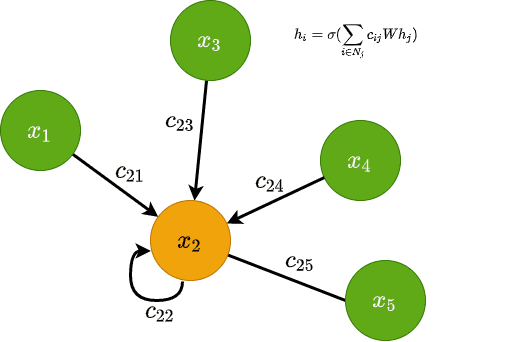

* **Пояснение:**
   - Все соседи $u$ и сам узел $v$ усредняются с нормализацией по степеням $(\deg(v)$, $\deg(u)$).
   - Матрица $W^{(l)}$ — единственный обучаемый линейный слой, который превращает «усреднённые» признаки в новое пространство.
   - $\sigma(\cdot)$ — нелинейность (ReLU и т.п.), добавляет модели выразительность.
   - Итог: узел получает сглаженный по соседям вектор признаков, отнормированный по структуре графа.

#### 2. GraphSAGE (SAmple and aggreGAtE) - `sage`
Архитектура, изначально созданная для работы с огромными графами.
* **Как работает:** Отдельно обрабатывает признаки самого узла и отдельно агрегирует (например, усредняет) признаки соседей. Затем эти два вектора **конкатенируются** (склеиваются) и пропускаются через линейный слой.
* **В чем силен:** За счет разделения «себя» и «соседей» часто выучивает более сложные паттерны, чем GCN. Отлично обобщается на новые, ранее не виданные узлы (индуктивное обучение). 
* **В чем слаб:** Простая агрегация (как среднее) может «размыть» важные, но редкие сигналы от специфических соседей.

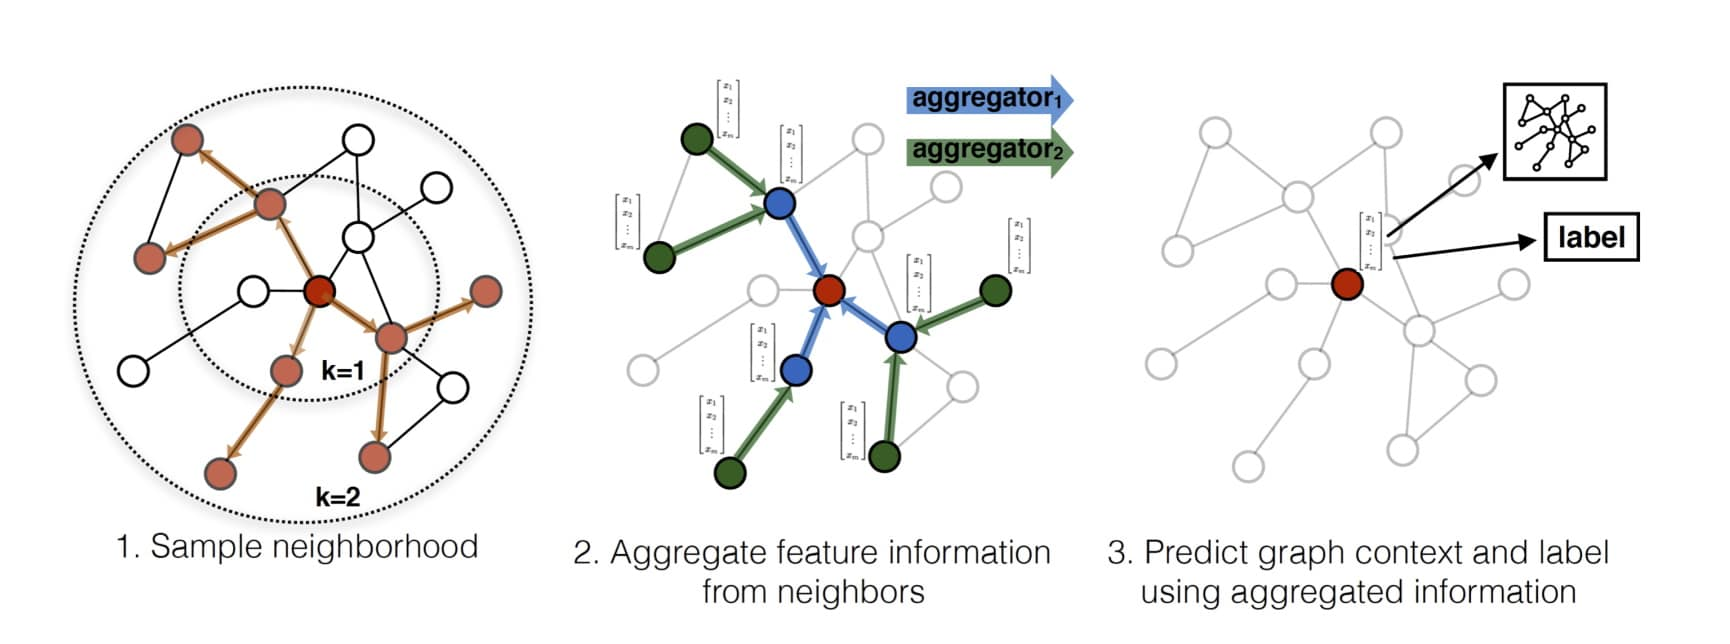

* **Формула:**
$$\mathbf{h}_v^{(l+1)} = \sigma\left(
    W_{\text{self}}^{(l)} \mathbf{h}_v^{(l)} \;+\;
    W_{\text{neigh}}^{(l)} \cdot 
    \text{mean}_{u \in \mathcal{N}(v)} \mathbf{h}_u^{(l)}
\right)$$
* **Пояснение:**
- Сначала считаем среднее по признакам всех соседей $\text{mean}_{u \in \mathcal{N}(v)} \mathbf{h}_u^{(l)}$.
- Отдельная матрица $W_{\text{self}}^{(l)}$ учит, как обрабатывать собственные признаки узла.
- Другая матрица $W_{\text{neigh}}^{(l)}$ учит, как обрабатывать агрегированную «среднюю» информацию от соседей.
- После сложения двух компонентов применяется активация $\sigma$.
- Итог: модель явно разделяет вклад «себя» и «окружения», что делает эмбеддинги более устойчивыми и интерпретируемыми.

#### 3. GAT (Graph Attention Network) - `gat`
Графовая сеть с механизмом внимания (Attention, как в трансформерах).
* **Как работает:** Вычисляет «коэффициент важности» для каждого соседа в зависимости от его признаков. При агрегации важные соседи получают больший вес, а фоновый шум — меньший.
* **В чем силен:** Самая выразительная архитектура из представленных. Может самостоятельно понять, что для Z-ДНК соседний эпигенетический маркер важнее, чем маркер через 3 нуклеотида, и дать ему больший вес.
* **В чем слаб:** Вычисление внимания для каждого ребра требует много памяти и вычислительных ресурсов. На маленьких датасетах легко переобучается.

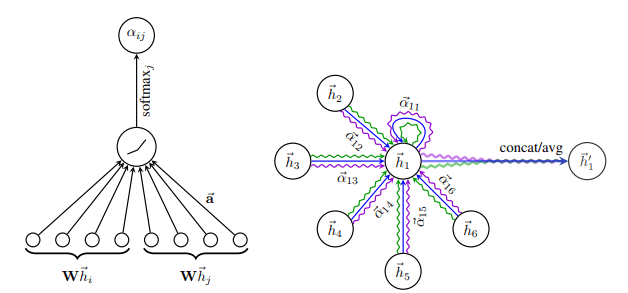

* **Формула:**
1. Линейное преобразование признаков узлов:
$$
\mathbf{h}'_v = W^{(l)} \mathbf{h}_v^{(l)}
$$

2. Вычисление «сырых» коэффициентов внимания по ребру \((v,u)\):
$$
e_{vu} = \text{LeakyReLU}\left(
    \mathbf{a}^{\top}
    \left[
        \mathbf{h}'_v \,\|\, \mathbf{h}'_u
    \right]
\right)
$$

3. Нормализация коэффициентов внимания (softmax по соседям):
$$
\alpha_{vu} = 
\frac{\exp(e_{vu})}
     {\sum_{k \in \mathcal{N}(v)} \exp(e_{vk})}
$$

4. Агрегация с учетом внимания:
$$
\mathbf{h}_v^{(l+1)} = \sigma\left(
    \sum_{u \in \mathcal{N}(v) \cup \{v\}} 
    \alpha_{vu} \, \mathbf{h}'_u
\right)
$$
* **Пояснение:**
- $W^{(l)}$ превращает признаки узлов в общее скрытое пространство.
- Вектор $\mathbf{a}$ инициализирует маленькую «однослойную сеть» поверх конкатенации $[\mathbf{h}'_v \| \mathbf{h}'_u]$ и учит, какие соседние узлы важнее.
- $\alpha_{vu}$ — нормализованный вес ребра, показывающий важность соседа $u$ для узла $v$.
- Итог: каждый узел получает взвешенную сумму признаков соседей, где веса $\alpha$ обучаются вместе с моделью и зависят от содержимого признаков.

#### 4. GraphConv (Vanilla Graph Convolution) - `graph`
Базовый пространственный графовый оператор в PyTorch Geometric.
* **Как работает:** Похож на GraphSAGE — он применяет одну матрицу весов к самому узлу ($W_1$), а другую — к сумме признаков всех его соседей ($W_2$), после чего складывает результаты.
* **В чем силен:** Очень простая пространственная логика, хорошо работает там, где важна не нормализованная сумма признаков соседей, а их абсолютное количество.
* **В чем слаб:** Нет сложной нормализации (как в GCN) или внимания (как в GAT), поэтому может страдать от проблемы "взрыва" значений признаков, если у узла очень много соседей.
* **Формула:**

$$
\mathbf{h}_v^{(l+1)} = \sigma\left(
    W_{\text{self}}^{(l)} \mathbf{h}_v^{(l)} \;+\;
    W_{\text{neigh}}^{(l)} \sum_{u \in \mathcal{N}(v)} \mathbf{h}_u^{(l)}
\right)
$$

* **Пояснение:**
- Как и в GraphSAGE, отдельно обрабатываются:
  - собственные признаки узла через $W_{\text{self}}^{(l)}$;
  - суммарные признаки соседей через $W_{\text{neigh}}^{(l)}$.
- Используется именно **сумма**, а не среднее, поэтому модель чувствительна к количеству соседей.
- $\sigma$ добавляет нелинейность.
- Итог: простой, но мощный оператор, который позволяет узлам различать «много соседей с маленькими признаками» и «мало соседей с большими признаками».

> **💡 Что выбрать?** Для задач на ДНК-последовательностях **GraphSAGE** часто является золотой серединой между скоростью работы и выразительной способностью, а **GAT** стоит попробовать, если вам кажется, что некоторые нуклеотиды/признаки в окне важнее других.


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GCNConv, GATConv, GraphConv

class GraphBlock(nn.Module):
    def __init__(self,
                 in_dim,
                 out_dim,
                 conv_type='sage',
                 activation='relu',
                 norm_type='batch',
                 norm_groups=32,
                 dropout_type='standard',
                 dropout_rate=0.0):
        """
        Модульный графовый блок, объединяющий слой свертки, нормализацию, активацию и dropout.

        Args:
            in_dim (int): Размерность входных признаков (фичей) узла
            out_dim (int): Размерность выходных признаков узла
            conv_type (str): Тип графовой свертки ('sage', 'gcn', 'gat', 'graph')
            activation (str): Функция активации ('relu', 'leaky_relu', 'elu', 'selu', None)
            norm_type (str): Тип нормализации ('group', 'batch', 'layer', None)
            norm_groups (int): Количество групп для групповой нормализации (GroupNorm)
            dropout_type (str): Тип слоя Dropout ('standard', 'alpha', None)
            dropout_rate (float): Вероятность обнуления нейрона в Dropout
        """
        super().__init__()

        # Инициализация графового сверточного слоя
        self.conv = self._get_conv_layer(conv_type, in_dim, out_dim)

        # Выбор функции активации
        self.activation = self._get_activation(activation)

        # Инициализация слоя нормализации (помогает бороться со смещением ковариат)
        self.norm = self._get_norm_layer(norm_type, out_dim, norm_groups)
        self.norm_type = norm_type

        # Инициализация регуляризации Dropout (предотвращает переобучение)
        self.dropout = self._get_dropout(dropout_type, dropout_rate)
        self.dropout_type = dropout_type

    def _get_conv_layer(self, conv_type, in_dim, out_dim):
        """Фабричный метод для выбора типа графовой свертки"""
        if conv_type == 'sage':
            return SAGEConv(in_dim, out_dim)
        elif conv_type == 'gcn':
            return GCNConv(in_dim, out_dim)
        elif conv_type == 'gat':
            return GATConv(in_dim, out_dim)
        elif conv_type == 'graph':
            return GraphConv(in_dim, out_dim)
        else:
            raise ValueError(f"Неизвестный тип свертки conv_type: {conv_type}")

    def _get_activation(self, activation):
        """Фабричный метод для выбора функции активации"""
        if activation == 'relu':
            return F.relu
        elif activation == 'leaky_relu':
            return lambda x: F.leaky_relu(x, negative_slope=0.01)
        elif activation == 'elu':
            return F.elu
        elif activation == 'selu':
            return F.selu
        elif activation is None:
            return lambda x: x  # Пропуск активации (Identity)
        else:
            raise ValueError(f"Неизвестная функция активации: {activation}")

    def _get_norm_layer(self, norm_type, num_channels, num_groups):
        """Фабричный метод для выбора слоя нормализации"""
        if norm_type == 'group':
            return nn.GroupNorm(num_groups=num_groups, num_channels=num_channels)
        elif norm_type == 'batch':
            return nn.BatchNorm1d(num_channels)
        elif norm_type == 'layer':
            return nn.LayerNorm(num_channels)
        elif norm_type is None:
            return nn.Identity()
        else:
            raise ValueError(f"Неизвестный тип нормализации norm_type: {norm_type}")

    def _get_dropout(self, dropout_type, dropout_rate):
        """Фабричный метод для выбора типа Dropout"""
        if dropout_type == 'standard' and dropout_rate > 0:
            return nn.Dropout(dropout_rate)
        elif dropout_type == 'alpha' and dropout_rate > 0:
            return nn.AlphaDropout(dropout_rate)
        else:
            return nn.Identity()

    def forward(self, x, edge_index):

        # 1. Применяем графовую свертку
        x = self.conv(x, edge_index)

        # 2. Применяем нормализацию
        # Для GroupNorm нужно поменять размерности местами (Batch, Channels, Length),
        # а затем вернуть обратно. Для других типов нормализации это не нужно.
        if self.norm_type == 'group':
            x = x.unsqueeze(0).permute(0, 2, 1)
            x = self.norm(x)
            x = x.permute(0, 2, 1).squeeze(0)
        else:
            x = self.norm(x)

        # 3. Применяем функцию активации
        x = self.activation(x)

        # 4. Применяем Dropout
        x = self.dropout(x)

        return x

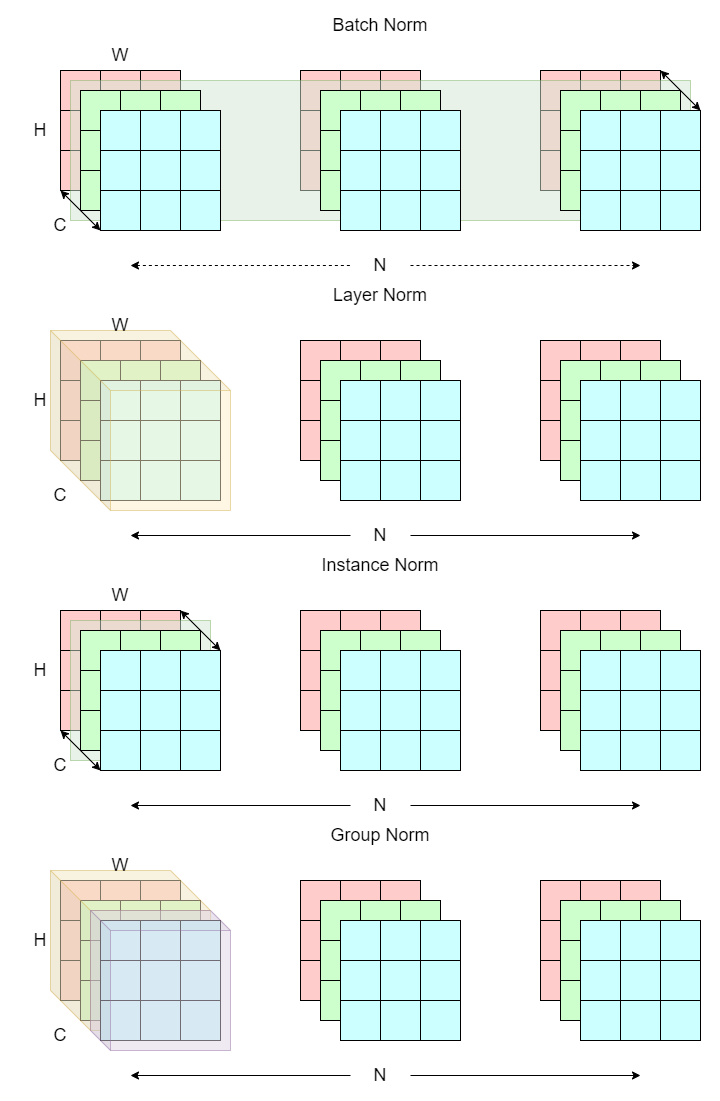

In [16]:
class GraphZSAGE(nn.Module):
    def __init__(self,
                 input_dim=1950,
                 output_dim=2,
                 hidden_dims=[1024, 1024, 512, 512, 256, 256, 128, 128, 64, 64],
                 conv_type='sage',
                 activation='relu',
                 norm_type='batch',
                 norm_groups=32,
                 dropout_type='standard',
                 dropout_rate=0.0,
                 **block_kwargs):
        """
        Полностью настраиваемая графовая нейронная сеть для предсказания Z-ДНК.

        Args:
            input_dim (int): Размерность входных фичей (длина OHE + эпигенетика)
            output_dim (int): Размерность выхода (2 класса: есть Z-ДНК или нет)
            hidden_dims (list): Список, задающий размерности скрытых слоев (определяет глубину сети)
            conv_type (str): Тип графовой свертки
            activation (str): Функция активации
            norm_type (str): Тип нормализации
            norm_groups (int): Количество групп для GroupNorm
            dropout_type (str): Тип Dropout
            dropout_rate (float): Вероятность Dropout
            block_kwargs: Дополнительные аргументы, прокидываемые в GraphBlock
        """
        super().__init__()

        # Создаем список скрытых графовых блоков (слоев)
        self.blocks = nn.ModuleList()
        prev_dim = input_dim
        
        # Строим архитектуру сети согласно переданному списку hidden_dims
        for dim in hidden_dims:
            self.blocks.append(
                GraphBlock(
                    in_dim=prev_dim,
                    out_dim=dim,
                    conv_type=conv_type,
                    activation=activation,
                    norm_type=norm_type,
                    norm_groups=norm_groups,
                    dropout_type=dropout_type,
                    dropout_rate=dropout_rate,
                    **block_kwargs
                )
            )
            prev_dim = dim  # Входная размерность следующего слоя равна выходной предыдущего

        # Финальный (выходной) слой: только свертка (без нормализации, активации и Dropout)
        self.out_conv = self._get_conv_layer(conv_type, prev_dim, output_dim)
        self.hidden_dims = hidden_dims

    def _get_conv_layer(self, conv_type, in_dim, out_dim):
        """Фабричный метод (такой же, как в GraphBlock, но для финального слоя)"""
        if conv_type == 'sage':
            return SAGEConv(in_dim, out_dim)
        elif conv_type == 'gcn':
            return GCNConv(in_dim, out_dim)
        elif conv_type == 'gat':
            return GATConv(in_dim, out_dim)
        elif conv_type == 'graph':
            return GraphConv(in_dim, out_dim)
        else:
            raise ValueError(f"Неизвестный тип свертки conv_type: {conv_type}")

    def forward(self, x, edge_index):
        
        # Пропускаем данные последовательно через все скрытые блоки
        for i, block in enumerate(self.blocks):
            x = block(x, edge_index)

        # Пропускаем через финальный слой
        x = self.out_conv(x, edge_index)
        
        return x

## Этап 3. Подготовка к обучению

### Кратко напомним про MLflow

In [21]:
import mlflow

# Создаем (или выбираем существующий) эксперимент в MLflow
mlflow.set_experiment("toy_demo")

# Запускаем новый экспериментальный прогон (run) с понятным именем
with mlflow.start_run(run_name="linear_reg_baseline"):
    # Логируем (записываем) гиперпараметр модели
    mlflow.log_param("model_type", "linear_regression")
    
    # Эмулируем процесс обучения: на каждом шаге считаем «loss» и логируем его
    for step in range(5):
        loss = 1.0 / (step + 1)  # игрушечная метрика, которая убывает по шагам
        # Логируем значение метрики 'loss' с указанием шага (step)
        mlflow.log_metric("loss", loss, step=step)
        print(loss)

1.0
0.5
0.3333333333333333
0.25
0.2


In [8]:
!mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
INFO:     Started parent process [74231]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'

### И к циклам обучения

In [24]:
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import mlflow 

# Выбор устройства для вычислений: используем видеокарту (GPU), если она доступна, иначе процессор (CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Инициализируем нашу модель и переносим её на выбранное устройство (CPU или GPU)
model = GraphZSAGE().to(device)

# Словарь с различными оптимизаторами для экспериментов
# Оптимизатор отвечает за обновление весов модели на основе вычисленных градиентов
optimizers = {
    # Adam: классический адаптивный оптимизатор, хороший выбор по умолчанию
    # lr - learning rate (шаг обучения), weight_decay - L2-регуляризация для предотвращения переобучения
    'Adam': optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4),
    
    # AdamW: модификация Adam с более правильной реализацией weight_decay
    'AdamW': optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3),
    
    # SGD (Стохастический градиентный спуск) с моментом
    # Часто дает лучшее качество в конце, но требует аккуратной настройки шага обучения
    'SGD': optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
}

# Словарь с планировщиками шага обучения (Learning Rate Schedulers)
# Они динамически меняют lr в процессе обучения, помогая модели лучше сойтись
schedulers = {
    # Умножает lr на gamma (0.1) каждые step_size (5) эпох
    'StepLR': lr_scheduler.StepLR(optimizers['Adam'], step_size=5, gamma=0.1),
    
    # Уменьшает lr, если целевая метрика (например, F1-score) перестает расти (mode='max')
    # patience=3: ждет 3 эпохи без улучшений, прежде чем уменьшить lr на factor (0.5)
    'ReduceLROnPlateau': lr_scheduler.ReduceLROnPlateau(
        optimizers['Adam'],
        mode='max',
        patience=3,
        factor=0.5,
    ),
    
    # Плавно уменьшает lr по косинусоиде от начального значения до eta_min за T_max шагов
    'Cosine': lr_scheduler.CosineAnnealingLR(
        optimizers['Adam'],
        T_max=10,
        eta_min=1e-6
    )
}

# Функция потерь (Loss function)
# CrossEntropyLoss используется для задачи многоклассовой (или бинарной) классификации.
# Параметр weight задает веса для классов. Здесь мы штрафуем модель сильнее (вес 2.0) 
# за ошибки на 1-м классе (наличие Z-ДНК), чтобы бороться с дисбалансом классов.
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, 2.0]).to(device)
)

Using device: cpu


In [25]:
import mlflow
import matplotlib.pyplot as plt

def train_epoch(model, dataloader, optimizer, criterion, device):
    """
    Обучает модель одну эпоху.
    """
    model.train()  # Переводим модель в режим обучения (включается Dropout, BatchNorm)
    running_loss = 0.0
    train_preds, train_targets = [], []
    
    # Проходим по всем батчам обучающей выборки
    for batch in tqdm(dataloader):
        optimizer.zero_grad()  # Обнуляем градиенты перед новым шагом
        
        # Прямой проход (forward pass): получаем предсказания модели
        out = model(batch.x.to(device), batch.edge_index.to(device))
        
        # Вычисляем ошибку (сравниваем с реальными метками y)
        loss = criterion(out, batch.y.to(device))
        
        # Обратный проход (backward pass): вычисляем градиенты
        loss.backward()
        
        # Обновляем веса модели
        optimizer.step()

        running_loss += loss.item()
        
        # Получаем предсказанные классы (индекс максимального значения)
        _, predicted = torch.max(out.data, 1)
        
        # Сохраняем предсказания и реальные метки для расчета метрик
        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(batch.y.cpu().numpy())

    # Вычисляем средний loss и макро-усредненный F1 score за эпоху
    epoch_loss = running_loss / len(dataloader)
    epoch_f1 = f1_score(train_targets, train_preds, average='macro')

    return epoch_loss, epoch_f1

def validate(model, dataloader, criterion, device):
    """
    Оценивает качество модели на валидационной выборке.
    """
    model.eval()  # Переводим модель в режим оценки (выключается Dropout)
    running_loss = 0.0
    val_preds, val_targets = [], []
    
    with torch.no_grad():  # Отключаем вычисление градиентов для ускорения и экономии памяти
        for batch in dataloader:
            out = model(batch.x.to(device), batch.edge_index.to(device))
            loss = criterion(out, batch.y.to(device))
            
            preds = out.argmax(dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(batch.y.cpu().numpy())
            running_loss += loss.item()

    val_f1 = f1_score(val_targets, val_preds, average='macro')
    val_loss = running_loss / len(dataloader)

    return val_loss, val_f1


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    device,
    epochs=20,
    use_mlflow=True, 
    experiment_name='zdna_gnn_project'
):
    """
    Основной цикл обучения модели с трекингом в MLflow.
    """
    if use_mlflow:
        # Устанавливаем имя эксперимента в MLflow (если его нет - он создастся)
        mlflow.set_experiment(experiment_name)
        # Начинаем новый запуск (run)
        mlflow.start_run()
        # здесь еще нужно по-хорошему логгировать все гиперпараметры модели
        
    best_val_f1 = 0.0
    history = {
        'train_loss': [], 'train_f1': [],
        'val_loss': [], 'val_f1': [],
        'lr': []
    }

    for epoch in range(epochs):
        # Обучение и валидация
        train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_f1 = validate(model, val_loader, criterion, device)

        # Обновление learning rate scheduler'а
        if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_f1)
        else:
            scheduler.step()

        # Текущий learning rate
        current_lr = optimizer.param_groups[0]['lr']

        # Логирование в локальный словарь
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train Loss: {train_loss:.4f} | F1: {train_f1:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | F1: {val_f1:.4f}")
        print(f"  LR: {current_lr:.6f}")

        # Логирование метрик в MLflow
        if use_mlflow:
            mlflow.log_metrics({
                "train_loss": train_loss,
                "train_f1": train_f1,
                "val_loss": val_loss,
                "val_f1": val_f1,
                "lr": current_lr
            }, step=epoch)

        # Сохранение весов лучшей модели по F1-score на валидации
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model.pth')
            # Опционально можно сразу логировать лучшую модель как артефакт в MLflow
            if use_mlflow:
                mlflow.log_artifact('best_model.pth')

    if use_mlflow:
        # Завершаем запуск после конца обучения
        mlflow.end_run()

    return history


def plot_training_history(history):
    """
    Визуализация кривых обучения (Loss, F1-score и изменение Learning Rate).
    """
    plt.figure(figsize=(12, 4))

    # График функции потерь (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # График F1-score
    plt.subplot(1, 2, 2)
    plt.plot(history['train_f1'], label='Train')
    plt.plot(history['val_f1'], label='Validation')
    plt.title('F1-score')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # График изменения Learning rate
    plt.figure(figsize=(6, 4))
    plt.plot(history['lr'])
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('LR')
    plt.show()


## Этап 4. Первый бой

2026/02/24 14:57:43 INFO mlflow.tracking.fluent: Experiment with name 'zdna-segmentation' does not exist. Creating a new experiment.


  0%|          | 0/638 [00:00<?, ?it/s]

Epoch 1/2:
  Train Loss: 0.2758 | F1: 0.5155
  Val Loss: 0.2563 | F1: 0.5421
  LR: 0.000500


  0%|          | 0/638 [00:00<?, ?it/s]

Epoch 2/2:
  Train Loss: 0.2479 | F1: 0.5655
  Val Loss: 0.2490 | F1: 0.6416
  LR: 0.000500


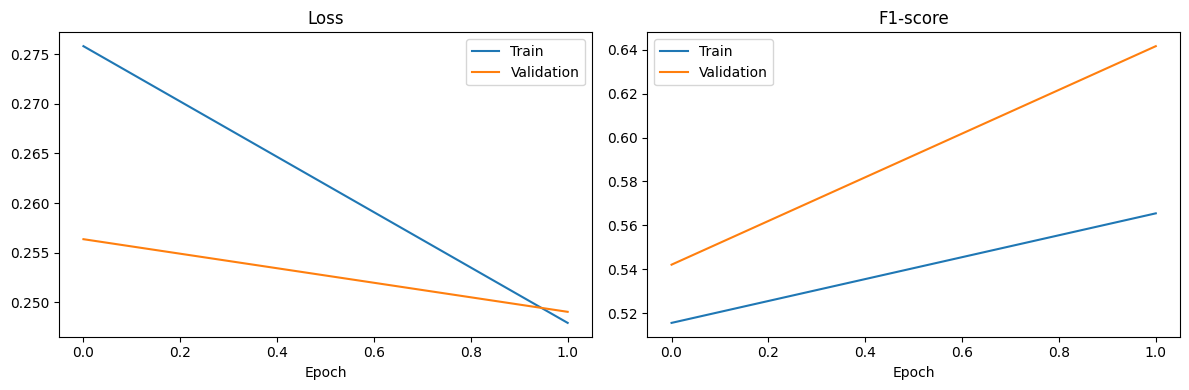

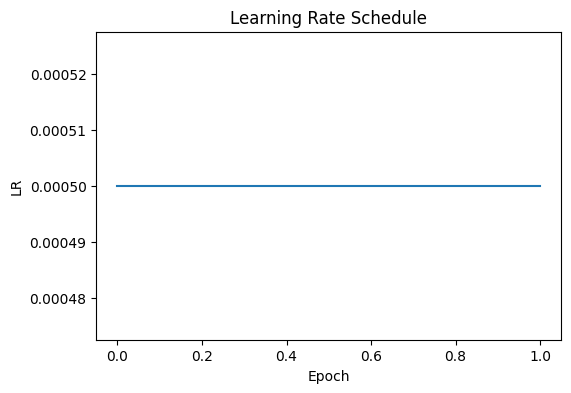

In [26]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizers['AdamW'],
    scheduler=schedulers['ReduceLROnPlateau'],
    criterion=criterion,
    device=device,
    epochs=2,
    use_mlflow=True, 
    experiment_name="zdna-segmentation"
)

plot_training_history(history)

## Этап 5. Optuna: Умный подбор гиперпараметров

In [27]:
!pip install optuna_integration -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Как она устроена?

В машинном обучении много параметров, которые мы задаем руками до начала обучения (learning rate, количество слоев, размер окна и т.д.). Они называются гиперпараметрами. Искать их идеальную комбинацию вручную — долго и неэффективно. Здесь на помощь приходит **Optuna**.

**Optuna** — это мощный фреймворк для автоматической оптимизации гиперпараметров. В отличие от простого перебора по сетке (GridSearch), Optuna использует умные математические алгоритмы (например, Байесовскую оптимизацию через TPE), чтобы предсказывать, какие комбинации параметров дадут лучший результат, основываясь на предыдущих попытках. Это позволяет найти лучшее решение за меньшее число шагов.

**Из чего состоит процесс в Optuna:**
1. **Trial (Попытка):** Один прогон (эксперимент) с конкретным набором гиперпараметров. У объекта `trial` есть методы `suggest_...`, которые "вытаскивают" случайное значение из заданного нами диапазона (например, `suggest_float("lr", 1e-5, 1e-2)`).
2. **Objective (Целевая функция):** Функция, которую мы хотим оптимизировать. Она принимает `trial`, внутри неё мы инициализируем модель с предложенными параметрами, обучаем её и возвращаем метрику (например, Loss или F1-score).
3. **Study (Исследование):** Сущность, которая управляет всем процессом оптимизации. Она запускает множество попыток (`n_trials`), запоминает их результаты и решает, в какую сторону двигаться дальше (минимизировать или максимизировать функцию).

Давайте посмотрим на максимально простом, «игрушечном» математическом примере, как это работает.


In [28]:
import optuna

# 1. Определяем целевую функцию (Objective)
# Эта функция принимает объект 'trial' и должна вернуть число (метрику), 
# которое Optuna будет пытаться минимизировать или максимизировать.
def simple_objective(trial):
    # Просим Optuna предложить вещественное (float) значение для переменной x в диапазоне от -10 до 10
    x = trial.suggest_float("x", -10, 10)
    
    # То же самое делаем для переменной y
    y = trial.suggest_float("y", -10, 10)
    
    # Вычисляем функцию: f(x,y) = (x - 2)^2 + (y + 3)^2
    # Математически, минимум этой функции равен 0, и достигается он при x=2, y=-3
    return (x - 2)**2 + (y + 3)**2

# 2. Создаем объект Study (Исследование)
# Указываем direction="minimize", так как мы хотим найти минимум нашей функции
study = optuna.create_study(direction="minimize")

# 3. Запускаем процесс оптимизации
# Optuna вызовет функцию simple_objective 30 раз (n_trials=30) с разными значениями x и y,
# пытаясь нащупать минимум.
study.optimize(simple_objective, n_trials=30)

# 4. Выводим результаты
print("Best params:", study.best_params) # Выведет найденные значения x и y (должны быть близки к 2 и -3)
print("Best value:", study.best_value)   # Выведет минимальное значение функции (должно быть близко к 0)

[I 2026-02-24 16:05:38,895] A new study created in memory with name: no-name-2c33dff7-fc2e-494a-ad29-ef514b7a30e0
[I 2026-02-24 16:05:38,901] Trial 0 finished with value: 97.26703382186385 and parameters: {'x': -7.799400074885137, 'y': -4.113010329783615}. Best is trial 0 with value: 97.26703382186385.
[I 2026-02-24 16:05:38,902] Trial 1 finished with value: 111.22389267690502 and parameters: {'x': -8.538471668711301, 'y': -2.594404678682971}. Best is trial 0 with value: 97.26703382186385.
[I 2026-02-24 16:05:38,903] Trial 2 finished with value: 44.2179941456335 and parameters: {'x': 8.351276132947147, 'y': -1.03040978153083}. Best is trial 2 with value: 44.2179941456335.
[I 2026-02-24 16:05:38,903] Trial 3 finished with value: 123.46736093097793 and parameters: {'x': -5.9113893090336695, 'y': 4.802389386071788}. Best is trial 2 with value: 44.2179941456335.
[I 2026-02-24 16:05:38,903] Trial 4 finished with value: 37.73031481816305 and parameters: {'x': -0.7272664281557906, 'y': 2.5038

Best params: {'x': 2.4651792838478688, 'y': -2.829266770722252}
Best value: 0.2455416017008242


### И по-серьезному теперь

In [29]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

import mlflow
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from sklearn.metrics import f1_score
import numpy as np
from torch_geometric.loader import DataLoader

def objective(trial):
    """
    Главная функция для Optuna. Внутри нее мы:
    1. Генерируем новый набор гиперпараметров.
    2. Создаем датасеты, Dataloader'ы и модель с этими параметрами.
    3. Обучаем модель несколько эпох.
    4. Возвращаем лучшую метрику (F1), чтобы Optuna знала, насколько хорош этот набор.
    """

    # --- 1. Параметры графа (датасета) ---
    num_neighbors = trial.suggest_int('num_neighbors', 1, 3)
    dilation = trial.suggest_int('dilation', 1, 3)

    train_dataset = GraphDataset(
        chrom_names, feature_names, DNA, DNA_features,
        ZDNA, train_intervals,
        num_neighbors=num_neighbors,
        dilation=dilation,
    )

    val_dataset = GraphDataset(
        chrom_names, feature_names, DNA, DNA_features,
        ZDNA, test_intervals,
        num_neighbors=num_neighbors,
        dilation=dilation,
    )

    # --- 2. Конфигурация архитектуры и обучения ---
    hidden_dims = [
        trial.suggest_categorical('dim1', [512, 1024]),
        trial.suggest_categorical('dim2', [256, 512]),
        trial.suggest_categorical('dim3', [128, 256]),
    ]

    conv_type   = trial.suggest_categorical('conv_type', ['sage', 'gcn', 'gat'])
    activation  = trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'elu'])
    norm_type   = trial.suggest_categorical('norm_type', ['batch', 'layer'])
    norm_groups = trial.suggest_int('norm_groups', 8, 64, step=8)
    dropout_type = trial.suggest_categorical('dropout_type', ['standard', 'alpha', None])
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5, step=0.1)

    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr_            = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay   = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    scheduler_name = trial.suggest_categorical('scheduler', ['ReduceLROnPlateau', 'Cosine', 'StepLR'])
    batch_size     = trial.suggest_categorical('batch_size', [16, 32, 64])

    config = {
        'hidden_dims': hidden_dims,
        'conv_type': conv_type,
        'activation': activation,
        'norm_type': norm_type,
        'norm_groups': norm_groups,
        'dropout_type': dropout_type,
        'dropout_rate': dropout_rate,
        'optimizer': optimizer_name,
        'lr': lr_,
        'weight_decay': weight_decay,
        'scheduler': scheduler_name,
        'batch_size': batch_size,
        'num_epochs': EPOCHS,
    }

    # --- 3. DataLoader'ы ---
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size)

    # --- 4. Модель ---
    model = GraphZSAGE(
        input_dim=1950,   
        output_dim=2,
        hidden_dims=hidden_dims,
        conv_type=conv_type,
        activation=activation,
        norm_type=norm_type,
        norm_groups=norm_groups,
        dropout_type=dropout_type,
        dropout_rate=dropout_rate,
    ).to(device)

    # --- 5. Оптимизатор ---
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr_, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=lr_, weight_decay=weight_decay)
    else:  # RMSprop
        optimizer = optim.RMSprop(model.parameters(), lr=lr_, weight_decay=weight_decay)

    # --- 6. Scheduler ---
    if scheduler_name == 'ReduceLROnPlateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
    elif scheduler_name == 'Cosine':
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    else:
        scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    # --- 7. Nested MLflow run для trial'а ---
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):

        # Логируем гиперпараметры trial'а
        mlflow.log_params({
            "num_neighbors": num_neighbors,
            "dilation": dilation,
            "conv_type": conv_type,
            "hidden_dims": "-".join(map(str, hidden_dims)),
            "activation": activation,
            "norm_type": norm_type,
            "norm_groups": norm_groups,
            "dropout_type": dropout_type,
            "dropout_rate": dropout_rate,
            "optimizer": optimizer_name,
            "lr": lr_,
            "weight_decay": weight_decay,
            "scheduler": scheduler_name,
            "batch_size": batch_size,
            "num_epochs": EPOCHS,
        })

        best_val_f1 = 0.0

        for epoch in range(EPOCHS):
            # одна эпоха обучения + валидация
            train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss,   val_f1   = validate(model, val_loader, criterion, device)

            # Обновляем scheduler
            if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()

            current_lr = optimizer.param_groups[0]['lr']

            # Логируем метрики в MLflow
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_f1",   train_f1,   step=epoch)
            mlflow.log_metric("val_loss",   val_loss,   step=epoch)
            mlflow.log_metric("val_f1",     val_f1,     step=epoch)
            mlflow.log_metric("lr",         current_lr, step=epoch)

            # Обновляем лучшую метрику
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                torch.save(model.state_dict(), "best_model_trial.pth")
                mlflow.log_artifact("best_model_trial.pth")

            # Сообщаем Optuna промежуточный результат
            trial.report(val_f1, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_f1

In [30]:
# --- Конфигурация исследования Optuna ---
def create_study():
    """Создает объект Study, который управляет оптимизацией."""
    return optuna.create_study(
        direction='maximize',  # Мы максимизируем F1 score (если бы был Loss, ставили бы minimize)
        
        # Sampler отвечает за то, КАК выбираются новые параметры.
        # TPE (Tree-structured Parzen Estimator) - умный алгоритм на основе Байесовской статистики.
        sampler=TPESampler(
            n_startup_trials=20,  # Первые 20 попыток выбираются случайно для разведки
            multivariate=True,    # Учитывает взаимосвязь (корреляцию) параметров друг с другом
            group=True            # Группирует зависимые параметры
        ),
        
        # Pruner отсекает (останавливает досрочно) попытки, которые показывают плохие результаты
        # MedianPruner отсекает попытку, если ее результат на текущей эпохе хуже медианы прошлых попыток
        pruner=MedianPruner(
            n_startup_trials=10,  # Не обрубаем первые 10 экспериментов (собираем статистику)
            n_warmup_steps=1,     # Даем каждой модели обучиться хотя бы 1 эпоху перед отсечением
            interval_steps=1      # Проверяем надобность остановки каждую 1 эпоху
        ),
        study_name='gnn_hyperopt',
        load_if_exists=True       # Если запустить ячейку снова, она продолжит старое исследование
    )

In [31]:
# --- Основной блок запуска ---
# Какие параметры мы оптимизируем?
# 1. Архитектура: размеры скрытых слоев, тип GNN свертки (SAGE/GCN/GAT), функции активации, нормализация, Dropout.
# 2. Обучение: тип оптимизатора, Learning Rate (LR), вес L2-регуляризации (weight_decay), планировщик LR, размер батча.


EPOCHS = 2           # Для экономии времени на семинаре обучаем каждую комбинацию всего 3 эпохи
N_TRIALS = 5       # Всего Optuna попробует 100 разных комбинаций (часть из них прервет досрочно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Инициализируем базу данных Optuna
sampler = TPESampler(seed=42)
pruner  = MedianPruner(n_startup_trials=3, n_warmup_steps=0)

mlflow.set_experiment("ZDNA_GNN_Optuna")

with mlflow.start_run(run_name="optuna_search"):
    # study = create_study()
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
    )
    # Запускаем сам процесс. Optuna будет вызывать функцию 'objective' N_TRIALS раз
    study.optimize(objective, n_trials=N_TRIALS)

2026/02/24 16:05:48 INFO mlflow.tracking.fluent: Experiment with name 'ZDNA_GNN_Optuna' does not exist. Creating a new experiment.
[I 2026-02-24 16:05:48,238] A new study created in memory with name: no-name-94dd66ed-6932-4f61-96e4-df9da7f39328


  0%|          | 0/638 [00:00<?, ?it/s]

  0%|          | 0/638 [00:00<?, ?it/s]

[I 2026-02-24 16:25:34,213] Trial 0 finished with value: 0.5135759957521814 and parameters: {'num_neighbors': 2, 'dilation': 3, 'dim1': 512, 'dim2': 256, 'dim3': 256, 'conv_type': 'gcn', 'activation': 'relu', 'norm_type': 'layer', 'norm_groups': 24, 'dropout_type': 'standard', 'dropout_rate': 0.30000000000000004, 'optimizer': 'RMSprop', 'lr': 8.168455894760161e-05, 'weight_decay': 0.0002267398652378039, 'scheduler': 'StepLR', 'batch_size': 32}. Best is trial 0 with value: 0.5135759957521814.


  0%|          | 0/638 [00:00<?, ?it/s]

...

  0%|          | 0/319 [00:00<?, ?it/s]

[I 2026-02-24 17:15:57,446] Trial 3 finished with value: 0.623596095011083 and parameters: {'num_neighbors': 2, 'dilation': 2, 'dim1': 1024, 'dim2': 512, 'dim3': 256, 'conv_type': 'sage', 'activation': 'relu', 'norm_type': 'batch', 'norm_groups': 64, 'dropout_type': None, 'dropout_rate': 0.4, 'optimizer': 'AdamW', 'lr': 0.00041198396246051877, 'weight_decay': 0.00048783606034521424, 'scheduler': 'ReduceLROnPlateau', 'batch_size': 64}. Best is trial 2 with value: 0.640581646616845.


  0%|          | 0/1276 [00:00<?, ?it/s]

  0%|          | 0/1276 [00:00<?, ?it/s]

[I 2026-02-24 17:30:49,931] Trial 4 finished with value: 0.5836713157943574 and parameters: {'num_neighbors': 1, 'dilation': 2, 'dim1': 512, 'dim2': 512, 'dim3': 128, 'conv_type': 'gcn', 'activation': 'relu', 'norm_type': 'batch', 'norm_groups': 24, 'dropout_type': 'alpha', 'dropout_rate': 0.0, 'optimizer': 'AdamW', 'lr': 1.9489008462344262e-05, 'weight_decay': 2.9400741309033083e-05, 'scheduler': 'ReduceLROnPlateau', 'batch_size': 16}. Best is trial 2 with value: 0.640581646616845.


In [32]:
print("Лучший эксперимент (Trial):")
trial = study.best_trial
print(f"  Максимальный F1-score: {trial.value:.4f}")
print("  Найденные лучшие гиперпараметры: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")
print("==============================\n")

# Сохраняем словарь с лучшими параметрами в файл
best_params = trial.params
torch.save(best_params, 'best_gnn_params.pth')

Лучший эксперимент (Trial):
  Максимальный F1-score: 0.6406
  Найденные лучшие гиперпараметры: 
    num_neighbors: 1
    dilation: 2
    dim1: 1024
    dim2: 512
    dim3: 128
    conv_type: gcn
    activation: leaky_relu
    norm_type: batch
    norm_groups: 56
    dropout_type: standard
    dropout_rate: 0.1
    optimizer: AdamW
    lr: 0.000594874681321977
    weight_decay: 2.6100256506134754e-05
    scheduler: StepLR
    batch_size: 32



## Этап 6. xAI methods

In [35]:
!pip3 install captum -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
whisperx 3.7.6 requires numpy>=2.1.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
torchvision 0.25.0 requires torch==2.10.0, but you have torch 2.8.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Интерпретация нейросетей с помощью Captum

До этого момента мы воспринимали модель как «черный ящик»: подаем на вход изображение, на выходе получаем класс (например, "кот" или "собака"). Но важно понимать *почему* модель так решила: на какие части картинки она опирается, когда делает предсказание.

[**Captum**](https://captum.ai/) — это библиотека от команды PyTorch, которая помогает интерпретировать модели глубокого обучения:
- показывает вклад (важность) отдельных пикселей, каналов, слоев;
- поддерживает разные методы объяснения (saliency, Grad-CAM, Integrated Gradients и др.);
- умеет работать как с обычными CNN, так и с более сложными архитектурами.

В этом примере мы возьмем уже обученную модель ResNet18 из `torchvision` и с помощью **Grad-CAM** посмотрим, *какие области изображения больше всего повлияли* на выбор класса. Grad-CAM удобно объяснять интуитивно: он показывает «куда смотрит» модель на последнем сверточном слое, когда делает предсказание.


In [2]:
!pip3 install torchvision -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 6.4 MB/s  0:00:12m0:00:0100:01m
  Attempting uninstall: torch
    Found existing installation: torch 2.8.0
    Uninstalling torch-2.8.0:
      Successfully uninstalled torch-2.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
whisperx 3.7.6 requires numpy>=2.1.0, but you have numpy 1.26.4 which is incompatible.
whisperx 3.7.6 requires torch~=2.8.0, but you have torch 2.10.0 which is incompatible.
torchaudio 2.8.0 requires torch==2.8.0, but you have torch 2.10.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Predicted class index: 208


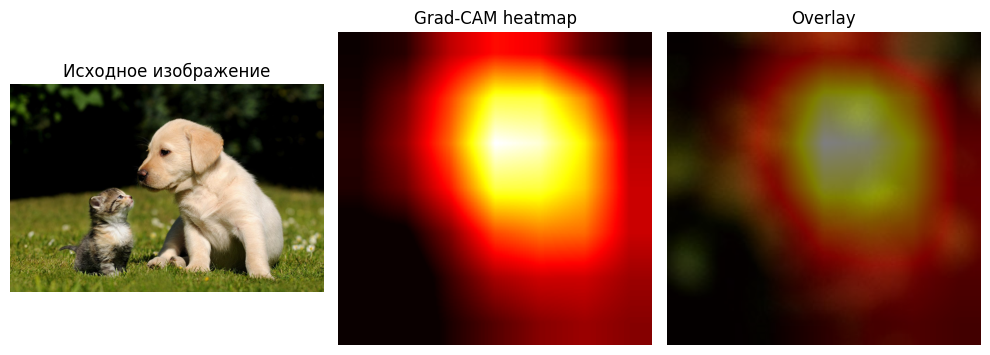

In [4]:
import torch
import torchvision.transforms as T
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from captum.attr import LayerGradCam, LayerAttribution

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Загружаем предобученную модель ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
model.eval()

# 2. Трансформации, как при обучении на ImageNet
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 3. Загружаем изображение
img = Image.open("cat_dog.jpg").convert("RGB")
input_tensor = transform(img).unsqueeze(0).to(device)  # [1,3,224,224]

# 4. Прямой проход и выбор целевого класса
with torch.no_grad():
    output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
print("Predicted class index:", pred_class)

# 5. Grad-CAM на последнем сверточном слое
# Для ResNet18 это layer4 (последний блок перед пулингом и полносвязной частью)
target_layer = model.layer4

gradcam = LayerGradCam(model, target_layer)

# Получаем карту атрибуций (важности) в пространстве признаков последнего сверточного слоя
attributions = gradcam.attribute(
    input_tensor,
    target=pred_class  # объясняем тот класс, который модель предсказала
)  # shape: [1, C, H_feat, W_feat]

# 6. Переводим атрибуты в «картинку» размера исходного изображения
# Берем среднее по каналам, чтобы получить одну карту важности [H_feat, W_feat]
attr = attributions.squeeze(0).mean(dim=0, keepdim=True)  # [1, H_feat, W_feat]

# Масштабируем до размера входного изображения (224x224)
# LayerAttribution.interpolate умеет это делать корректно
# attr: [1, H_feat, W_feat]
attr_upsampled = LayerAttribution.interpolate(
    attr.unsqueeze(0),              # [1,1,H_feat,W_feat]
    input_tensor.shape[2:],         # (H, W) = (224, 224)
    interpolate_mode="bilinear",
).squeeze().detach().cpu().numpy()  # -> [H, W]


# Нормализуем карту важности в [0,1]
attr_upsampled = np.maximum(attr_upsampled, 0)  # Grad-CAM обычно берёт только положительные значения
attr_upsampled = (attr_upsampled - attr_upsampled.min()) / (
    attr_upsampled.max() - attr_upsampled.min() + 1e-8
)

# 7. Рисуем результат: исходное изображение, heatmap и наложение
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.title("Исходное изображение")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Grad-CAM heatmap")
plt.imshow(attr_upsampled, cmap="hot")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img)
plt.imshow(attr_upsampled, cmap="hot", alpha=0.5)
plt.axis("off")

plt.tight_layout()
plt.show()

### Основные методы интерпретации в Captum (Как это работает?)

Библиотека Captum реализует множество алгоритмов (Saliency, Grad-CAM, Integrated Gradients, DeepLIFT и др.). Все они решают одну задачу: **присвоить каждому входному признаку (пикселю, нуклеотиду, фиче) оценку важности (attribution score)**.

Методы интерпретации делятся на две большие группы:
1. **Градиентные (Gradient-based):** смотрят на производные (градиенты) внутри сети при обратном проходе. Работают быстро.
2. **Основанные на возмущениях (Perturbation-based):** зашумляют, удаляют или перекрывают (occlude) части входа и смотрят, как сильно упадет уверенность сети. Работают медленнее, но иногда точнее.

Разберем 3 самых популярных градиентных метода "на пальцах":

#### 1. Saliency (Базовые градиенты)
Самый старый и простой подход. 
* **Как работает:** Мы делаем обычный прямой проход (forward), получаем предсказание, а затем берем производную (градиент) этого предсказания по *входным признакам* $\frac{\partial(Output)}{\partial(Input)}$. Если производная большая, значит небольшое изменение этого пикселя/нуклеотида сильно меняет предсказание сети.
* **Плюсы:** Работает моментально, проще всего понять.
* **Минусы:** Очень зашумленная картинка. Страдает от "насыщения градиентов" (gradient saturation): если признак уже очень сильный (например, яркий пиксель), то его градиент может стать равным нулю (модель "насытилась" им), и Saliency скажет, что пиксель неважен, хотя это не так.

#### 2. Grad-CAM (Gradient-weighted Class Activation Mapping)
Классика для визуальных задач и сверточных сетей (CNN).
* **Как работает:** Вместо того чтобы считать градиенты до самого входа, Grad-CAM спускается только до *последнего сверточного слоя*. Он смотрит на то, как сильно активация каждого фильтра (канала) на этом слое влияет на итоговый класс. Затем он берет взвешенную сумму этих фильтров и масштабирует ее до размера исходной картинки.
* **Плюсы:** Дает очень красивые, сглаженные "тепловые карты" (heatmaps), выделяющие целые объекты (например, морду кота).
* **Минусы:** Карта получается размытой (разрешение последнего сверточного слоя обычно очень низкое, например $7\times7$). Не подходит для табличных данных или полносвязных сетей (нужна пространственная структура сверток).

#### 3. Integrated Gradients (Интегрированные Градиенты)
Один из самых мощных и теоретически обоснованных современных методов. Именно его мы использовали для нашей Z-ДНК.
* **Как работает:** Решает проблему "насыщения" Saliency. Метод берет "базовый вход" (baseline) — например, абсолютно черный экран или нулевой вектор. Затем он создает серию промежуточных шагов, плавно превращая этот "нулевой" вход в наш реальный. На *каждом* шаге считаются градиенты, а затем они усредняются (интегрируются).
* **Плюсы:** Очень точный. В отличие от Saliency, не теряет важные признаки, если сеть ими "перенасытилась". Отлично работает не только с картинками, но и с текстами, графами и таблицами.
* **Минусы:** Требует больше вычислительных ресурсов (нужно сделать 20-50 проходов через сеть для одного примера).

### Вспомним про нашу графовую архитектуру

Мы обучили модель, и она показывает хороший F1-score. Но как понять, *почему* она считает конкретный нуклеотид частью Z-ДНК? Какие именно эпигенетические маркеры (или соседние нуклеотиды) заставили ее сделать такой вывод?

Для этого мы используем **Captum** в связке с `torch_geometric.explain`.
В этом блоке мы применим метод **Integrated Gradients (Интегрированные Градиенты)**.

**Как это работает на графах:**
1. Мы берем датасет и прогоняем модель, чтобы найти **True Positive (TP)** предсказания — то есть те нуклеотиды, где Z-ДНК реально есть, и модель это правильно угадала.
2. Для каждого такого нуклеотида метод `IntegratedGradients` вычисляет важность (attribution) *каждого признака* (каждого столбца матрицы фичей).
3. Мы усредняем эти "карты важности" по всем правильно угаданным нуклеотидам во всех батчах валидационной выборки.
4. Выводим Топ-15 самых важных фичей. Это позволит нам сказать биологам: *"Наша модель выучила, что для формирования Z-ДНК важнее всего маркеры X и Y"*.

In [ ]:
import captum
from captum.attr import IntegratedGradients
from torch_geometric.explain import Explainer, CaptumExplainer
import matplotlib.pyplot as plt
import numpy as np

# Переводим модель на GPU и обязательно в режим оценки (чтобы отключить Dropout и пр.)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Создаем объект Explainer из PyTorch Geometric. 
# Он служит "мостом" между нашей GNN и алгоритмами Captum.
explainer = Explainer(
    model=model,  
    algorithm=CaptumExplainer("IntegratedGradients"),  # Выбираем метод интерпретации
    explanation_type="model",
    node_mask_type="attributes",  # Мы хотим понять важность конкретных ФИЧЕЙ в узлах (а не самих узлов)
    edge_mask_type="object",      # Можно игнорировать (мы не оцениваем важность отдельных ребер сейчас)
    model_config=dict(
        mode="multiclass_classification",  # У нас классификация на 2 класса
        task_level="node",                 # Предсказание делается для каждого узла
        return_type="logits",           # Наша модель возвращает logits
    ),
)

In [ ]:
%%time
# Длина окна (из настроек датасета)
width = 100          
# Количество признаков узла (4 нуклеотида + эпигенетика)
features_count = 1950 

# Здесь будем накапливать суммарную важность (node_mask) по всем графах
mean_importance = np.zeros(features_count, dtype=float)
successful_batches = 0

print("Запуск интерпретации на валидационной выборке...")

# Проходим по всем батчам из валидационной выборки
for dt in tqdm(val_loader):
    x = dt.x.to(device)
    edge = dt.edge_index.to(device)
    y = dt.y.to(device).long()
    
    with torch.no_grad():
        output = model(x, edge)
        pred = torch.argmax(output, dim=-1)

    # Находим индексы узлов, которые модель предсказала верно как Z-DNA (True Positive)
    # y[0] и pred[0] используются, потому что у нас батч из 1 графа с N узлами
    tp_idxs = []
    for i in range(width):
        if pred[0][i] == y[0][i] and y[0][i] == 1:
            tp_idxs.append(i)

    # Если в этом графе модель не нашла ни одного Z-DNA узла (или ошиблась), пропускаем его
    if len(tp_idxs) == 0:
        continue

    # Очищаем кэш GPU перед тяжелыми вычислениями градиентов
    torch.cuda.empty_cache()
    
    # Запускаем Explainer! Просим объяснить почему модель предсказывает класс 1 (Z-DNA)
    explanation = explainer(x, edge, target=1)
    
    # Получаем карту важности фичей. Размерность: [seq_len, features_count]
    node_mask = explanation.node_mask
    
    # Оставляем только те строки (узлы), которые являются True Positive
    tp_attrs = node_mask[tp_idxs, :]
    
    # Усредняем важность признаков по всем TP-узлам внутри текущего графа
    mean_tp_attr = torch.mean(tp_attrs, dim=0).cpu().detach().numpy()
    
    # Прибавляем к общей статистике
    mean_importance += mean_tp_attr
    successful_batches += 1

print(f'\nИнтерпретация завершена! Обработано графов с TP предсказаниями: {successful_batches}')

In [ ]:
if successful_batches > 0:
    # Усредняем по всем батчам
    final_importance = mean_importance / successful_batches
    
    # Берем важность по модулю (нас интересует сила влияния, неважно, плюс это или минус)
    scores = np.abs(final_importance)
    
    # Находим индексы топ-15 самых сильных признаков
    top_k = 15
    top_idx = np.argsort(-scores)[:top_k]
    top_scores = scores[top_idx]
    
    # Получаем человекочитаемые названия признаков
    # Первые 4 признака (0,1,2,3) - это буквы ДНК. Остальные - из списка feature_names
    top_labels = [feature_names[i - 4] if i >= 4 else f"DNA_base_{i}" for i in top_idx]
    
    # Строим график
    plt.figure(figsize=(12, 5))
    plt.bar(range(top_k), top_scores, color='skyblue', edgecolor='black')
    plt.xticks(
        range(top_k),
        top_labels,
        rotation=45,
        ha='right'
    )
    plt.ylabel("Важность (Integrated Gradients)")
    plt.title(f"Топ-{top_k} самых важных признаков для формирования Z-ДНК")
    plt.tight_layout()
    plt.show()
else:
    print("Не найдено верно предсказанных узлов Z-DNA для визуализации.")